# Анализ данных «Карты ДТП»

**Цель проекта:** проверить качество данных, найти пропуски и дубликаты, проверить типы данных и исследовать, как число ДТП зависит от времени и стажа водителей.

Дополнительно сравним динамику ДТП в Кировской и Московской областях.


## 1. Загрузка данных

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

url = 'https://code.s3.yandex.net/datasets/'

# Таблицы с самими ДТП
kirov = pd.read_csv(url + 'Kirovskaya_oblast.csv')
moscow = pd.read_csv(url + 'Moscowskaya_oblast.csv')

# Таблицы с участниками ДТП
kirov_part = pd.read_csv(url + 'Kirovskaya_oblast_participiants.csv')
moscow_part = pd.read_csv(url + 'Moscowskaya_oblast_participiants.csv')

# Таблицы с транспортными средствами
kirov_veh = pd.read_csv(url + 'Kirovskaya_oblast_vehicles.csv')
moscow_veh = pd.read_csv(url + 'Moscowskaya_oblast_vehicles.csv')

print('Кировская область, ДТП:', kirov.shape)
print('Московская область, ДТП:', moscow.shape)

Кировская область, ДТП: (14517, 18)
Московская область, ДТП: (45618, 18)


## 2. Названия столбцов

В таблицах ДТП названия вида `properties.datetime` неудобны: с ними долго писать код. Уберём слово `properties.` и заменим точки на нижнее подчёркивание.

In [2]:
kirov.columns = kirov.columns.str.replace('properties.', '', regex=False)
kirov.columns = kirov.columns.str.replace('.', '_', regex=False)

moscow.columns = moscow.columns.str.replace('properties.', '', regex=False)
moscow.columns = moscow.columns.str.replace('.', '_', regex=False)

print(kirov.columns.tolist())

['geometry_coordinates', 'id', 'tags', 'light', 'point_lat', 'point_long', 'nearby', 'region', 'scheme', 'address', 'weather', 'category', 'datetime', 'injured_count', 'parent_region', 'road_conditions', 'participants_count', 'participant_categories']


В таблицах участников и машин названия столбцов уже удобные, их менять не нужно.

## 3. Первый взгляд на данные и типы

In [3]:
kirov.head()

,geometry_coordinates,id,tags,light,point_lat,point_long,nearby,region,scheme,address,weather,category,datetime,injured_count,parent_region,road_conditions,participants_count,participant_categories
0,"[47.875603, 57.24379]",1983180,Дорожно-транспортные происшествия,Светлое время суток,57.243790,47.875603,[],Яранский район,600.0,Р-176 Вятка Чебоксары - Йошкар-Ола - Киров - С...,['Дождь'],Опрокидывание,2017-07-01 18:00:00,1,Кировская область,['Мокрое'],3,['Все участники']
1,"[47.87903, 57.304807]",2889433,Дорожно-транспортные происшествия,Светлое время суток,57.304807,47.879030,"['Административные здания', 'Нерегулируемый пе...",Яранский район,710.0,"г Яранск, ул Кирова, 10",['Ясно'],Наезд на пешехода,2023-09-12 17:10:00,1,Кировская область,"['Сухое', 'Отсутствие, плохая различимость гор...",2,"['Все участники', 'Пешеходы']"
2,"[47.840781, 57.297156]",2591208,Дорожно-транспортные происшествия,Сумерки,57.297156,47.840781,"['Жилые дома индивидуальной застройки', 'Нерег...",Яранский район,NaN,"г Яранск, ул Чапаева, 80",['Пасмурно'],Съезд с дороги,2021-07-02 21:25:00,1,Кировская область,['Мокрое'],1,['Все участники']
3,"[47.834365, 57.244775]",2577639,Дорожно-транспортные происшествия,Светлое время суток,57.244775,47.834365,['Жилые дома индивидуальной застройки'],Яранский район,200.0,"м Знаменка, ул Кирова, 15",['Пасмурно'],Столкновение,2021-05-31 18:55:00,1,Кировская область,['Сухое'],2,"['Все участники', 'Мотоциклисты']"
4,"[47.968197, 57.357738]",1981026,Дорожно-транспортные происшествия,Светлое время суток,57.357738,47.968197,['Нерегулируемый перекрёсток неравнозначных ул...,Яранский район,NaN,"с/п Никольское, Киров-Советск- Яранск - подъез...",['Ясно'],Опрокидывание,2018-05-16 16:25:00,2,Кировская область,"['Сухое', 'Отсутствие, плохая различимость гор...",2,['Все участники']


In [4]:
kirov.info()

<class 'pandas.DataFrame'>
RangeIndex: 14517 entries, 0 to 14516
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   geometry_coordinates    14517 non-null  str    
 1   id                      14517 non-null  int64  
 2   tags                    14517 non-null  str    
 3   light                   14517 non-null  str    
 4   point_lat               14485 non-null  float64
 5   point_long              14485 non-null  float64
 6   nearby                  14517 non-null  str    
 7   region                  14517 non-null  str    
 8   scheme                  13380 non-null  float64
 9   address                 13843 non-null  str    
 10  weather                 14517 non-null  str    
 11  category                14517 non-null  str    
 12  datetime                14517 non-null  str    
 13  injured_count           14517 non-null  int64  
 14  parent_region           14517 non-null  str    
 

Посмотрите на столбец `Dtype`. Столбец `datetime` скорее всего хранится как текст (`object`), а для работы с датами нужен специальный тип. Переведём его.

In [5]:
kirov['datetime'] = pd.to_datetime(kirov['datetime'])
moscow['datetime'] = pd.to_datetime(moscow['datetime'])

print(kirov['datetime'].dtype)

datetime64[us]



`datetime` нужно хранить как дату и время — это уже исправлено ниже.
`id`, `injured_count` и `participants_count` — числовые столбцы.
`point_lat` и `point_long` — вещественные числа, так как это координаты.
`scheme` содержит числовые значения, но есть пропуски, поэтому менять его тип без дополнительной обработки не будем.
Столбцы со строками и списками пока оставим как есть: для задач этого проекта этого достаточно.


## 4. Пропуски (Кировская область)

In [6]:
# Сколько пропусков в каждом столбце
missing = kirov.isna().sum()

# Оставим только столбцы, где пропуски есть
missing[missing > 0]

point_lat       32
point_long      32
scheme        1137
address        674
dtype: int64

In [7]:
# Доля пропусков в процентах
(kirov.isna().mean() * 100).round(1)

geometry_coordinates      0.0
id                        0.0
tags                      0.0
light                     0.0
point_lat                 0.2
point_long                0.2
nearby                    0.0
region                    0.0
scheme                    7.8
address                   4.6
weather                   0.0
category                  0.0
datetime                  0.0
injured_count             0.0
parent_region             0.0
road_conditions           0.0
participants_count        0.0
participant_categories    0.0
dtype: float64


Основные пропуски находятся в `scheme`, `address` и координатах.
Для `scheme` сначала стоит выяснить у заказчика, почему схема иногда не заполняется. Искусственно подставлять значения не стоит.
Для `address` часть пропусков может быть связана с тем, что адрес не был указан. Если адрес нужен для анализа, его лучше сделать обязательным.
Для `point_lat` и `point_long` пропуски лучше не заполнять случайными значениями. Эти поля желательно сделать обязательными при сборе данных.
Удалять все строки с пропусками тоже не стоит: вместе с ними можно потерять реальные ДТП.


## 5. Дубликаты

### Явные дубликаты (полностью одинаковые строки)

In [8]:
print('Кировская область, ДТП:', kirov.duplicated().sum())
print('Московская область, ДТП:', moscow.duplicated().sum())
print('Кировская область, участники:', kirov_part.duplicated().sum())
print('Московская область, участники:', moscow_part.duplicated().sum())
print('Кировская область, машины:', kirov_veh.duplicated().sum())
print('Московская область, машины:', moscow_veh.duplicated().sum())

Кировская область, ДТП: 0
Московская область, ДТП: 0
Кировская область, участники: 9727
Московская область, участники: 35428
Кировская область, машины: 18
Московская область, машины: 706


In [9]:
print(
    'Доля полных дубликатов в Кировской области:',
    round(kirov.duplicated().mean() * 100, 2), '%'
)
print(
    'Доля полных дубликатов в Московской области:',
    round(moscow.duplicated().mean() * 100, 2), '%'
)


Доля полных дубликатов в Кировской области: 0.0 %
Доля полных дубликатов в Московской области: 0.0 %


Полные дубликаты в таблицах ДТП отсутствуют. Для таблиц участников и машин одинаковые строки не обязательно являются ошибкой: в одном ДТП могут участвовать несколько похожих объектов.

Поэтому дополнительно проверим уникальность `id` и совпадения даты, времени и координат.


### Уникальность идентификаторов и неявные дубликаты

In [10]:
# В таблице ДТП каждый id должен встречаться один раз
print('Кировская область, id уникальны:', kirov['id'].is_unique)
print('Московская область, id уникальны:', moscow['id'].is_unique)

Кировская область, id уникальны: True
Московская область, id уникальны: True


In [11]:
# Проверяем совпадения по дате, времени и координатам
print(
    'Кировская область:',
    kirov.duplicated(subset=['datetime', 'point_lat', 'point_long']).sum()
)
print(
    'Московская область:',
    moscow.duplicated(subset=['datetime', 'point_lat', 'point_long']).sum()
)


Кировская область: 0
Московская область: 0


In [12]:
# Смотрим глазами, нет ли одинаковых значений, записанных по-разному
# (например, «Москва» и «г. Москва»)
kirov['region'].value_counts()

region
Киров                     7512
Кирово-Чепецки район      1045
Слободской район           749
Котельничский район        485
Вятско-Полянский район     393
Оричевский район           334
Омутнинский район          333
Юрьянский район            320
Яранский район             310
Белохолуницкий район       211
Советский район            201
Малмыжский район           190
Орловский район            187
Нолинский район            163
Верхошижемский район       154
Уржумский район            153
Куменский район            140
Афанасьевский район        138
Зуевский район             122
Шабалинский район          103
Лузский район               96
Пижанский район             87
Подосиновский район         86
Мурашинский район           84
Даровской район             82
Сунский район               79
Кильмезский район           77
Кикнурский район            74
Арбажский район             74
Свечинский район            71
Верхнекамский район         61
Лебяжский район             59
Н

In [13]:
kirov['category'].value_counts()

category
Столкновение                                                                                                 5423
Наезд на пешехода                                                                                            4364
Съезд с дороги                                                                                               1155
Опрокидывание                                                                                                1002
Падение пассажира                                                                                             738
Наезд на препятствие                                                                                          667
Наезд на велосипедиста                                                                                        589
Наезд на стоящее ТС                                                                                           312
Иной вид ДТП                                                                   

## 6. ДТП по дням недели и месяцам

In [14]:
# Добавим в каждую таблицу название региона и склеим их в одну
kirov['oblast'] = 'Кировская область'
moscow['oblast'] = 'Московская область'
dtp = pd.concat([kirov, moscow], ignore_index=True)

# Из даты достаём день недели (0 = понедельник), месяц и год
dtp['weekday'] = dtp['datetime'].dt.dayofweek
dtp['month'] = dtp['datetime'].dt.month
dtp['year'] = dtp['datetime'].dt.year

In [15]:
# Считаем ДТП по дням недели
days = {0: 'Пн', 1: 'Вт', 2: 'Ср', 3: 'Чт', 4: 'Пт', 5: 'Сб', 6: 'Вс'}

by_weekday = dtp.groupby(['weekday', 'oblast']).size().unstack()
by_weekday = by_weekday.rename(index=days)
by_weekday

oblast,Кировская область,Московская область
weekday,,
Пн,2010,6390
Вт,1988,6156
Ср,1939,6102
Чт,1936,6343
Пт,2344,7024
Сб,2246,7285
Вс,2054,6318


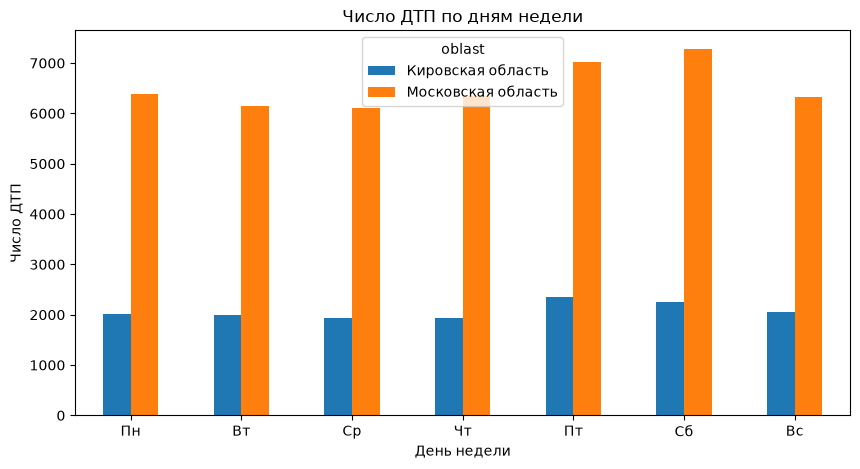

In [16]:
by_weekday.plot(kind='bar', figsize=(10, 5))
plt.title('Число ДТП по дням недели')
plt.xlabel('День недели')
plt.ylabel('Число ДТП')
plt.xticks(rotation=0)
plt.show()

In [17]:
# Считаем ДТП по месяцам
by_month = dtp.groupby(['month', 'oblast']).size().unstack()
by_month

oblast,Кировская область,Московская область
month,,
1,1069,3254
2,808,2744
3,799,2880
4,875,3172
5,1189,3992
6,1421,4354
7,1635,4401
8,1654,4787
9,1370,4571


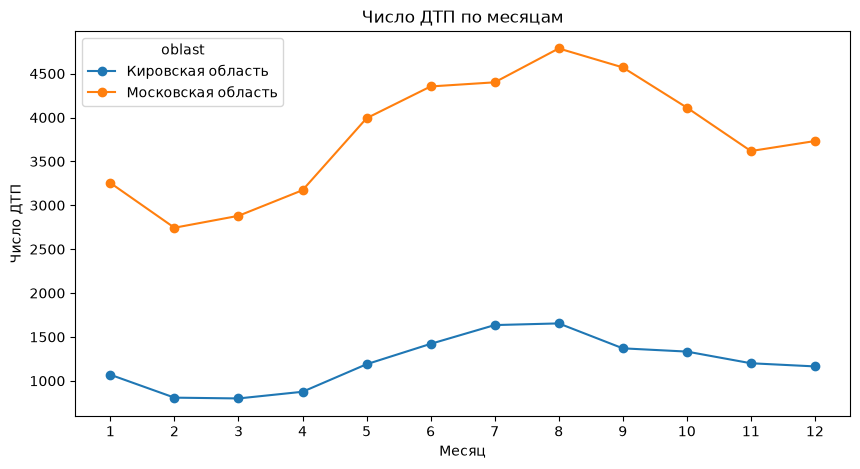

In [18]:
by_month.plot(kind='line', marker='o', figsize=(10, 5))
plt.title('Число ДТП по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Число ДТП')
plt.xticks(range(1, 13))
plt.show()


В Кировской области больше всего ДТП приходится на **пятницу**, а в Московской — на **субботу**. В обеих областях летом ДТП происходит больше, чем зимой. Максимальное число ДТП в обеих таблицах приходится на **август**.
При этом простое сравнение абсолютного числа ДТП между областями не совсем корректно, потому что численность населения отличается.


## 7. ДТП и стаж водителей

In [29]:
# Склеиваем участников двух областей
kirov_part['oblast'] = 'Кировская область'
moscow_part['oblast'] = 'Московская область'
participants = pd.concat([kirov_part, moscow_part], ignore_index=True)

# Какие бывают роли? Нужно точное написание значения для водителя
participants['role'].value_counts()

role
Водитель                                                                                                                            84269
Пассажир                                                                                                                            23439
Пешеход                                                                                                                             17065
Велосипедист                                                                                                                         1261
Пешеход, перед ДТП находившийся в (на) ТС в качестве водителя или пешеход, перед ДТП находившийся в (на) ТС в качестве пассажира      378
Name: count, dtype: int64

In [30]:
# Оставляем только водителей
drivers = participants[participants['role'] == 'Водитель'].copy()

# Проверяем стаж
print(drivers['years_of_driving_experience'].describe())

print('\nПропусков в стаже:', drivers['years_of_driving_experience'].isna().sum())


count    76588.000000
mean        15.738184
std         11.388112
min          1.000000
25%          7.000000
50%         14.000000
75%         22.000000
max         69.000000
Name: years_of_driving_experience, dtype: float64

Пропусков в стаже: 7681


In [31]:
# Делим стаж на понятные группы
bins = [-1, 2, 5, 10, 20, 100]
labels = ['до 2 лет', '3–5 лет', '6–10 лет', '11–20 лет', 'более 20 лет']

drivers['exp_group'] = pd.cut(
    drivers['years_of_driving_experience'],
    bins=bins,
    labels=labels
)

# Считаем уникальные ДТП в каждой группе
exp_counts = drivers.groupby(
    ['exp_group', 'oblast'],
    observed=False
)['id'].nunique().unstack()

exp_counts


oblast,Кировская область,Московская область
exp_group,,
до 2 лет,947,2895
3–5 лет,1405,4134
6–10 лет,2126,6921
11–20 лет,3312,11264
более 20 лет,3354,9936


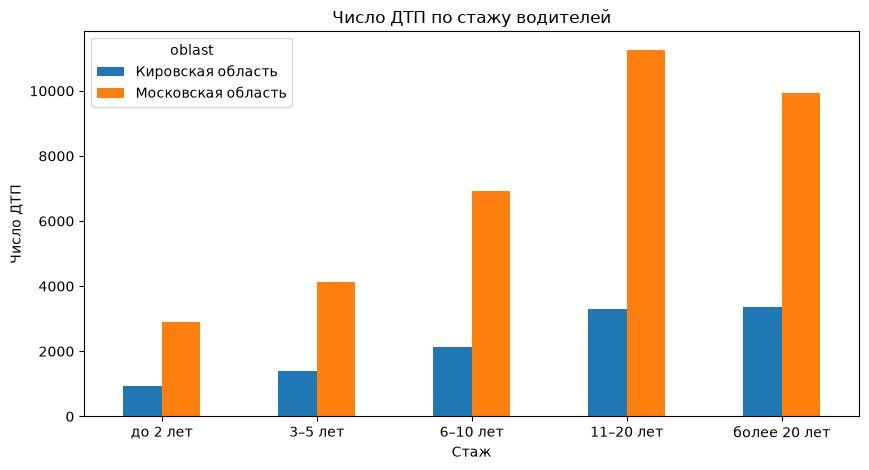

In [22]:
exp_counts.plot(kind='bar', figsize=(10, 5))
plt.title('Число ДТП по стажу водителей')
plt.xlabel('Стаж')
plt.ylabel('Число ДТП')
plt.xticks(rotation=0)
plt.show()


Количество ДТП в группах по стажу отличается: больше всего ДТП приходится на водителей со стажем **11–20 лет и более 20 лет**.

Но по этим данным нельзя сделать вывод, что опытные водители чаще попадают в ДТП. В каждой группе разное количество водителей, а у части водителей стаж не заполнен. Для корректного сравнения нужна численность водителей в каждой группе.

Следует сделать поле со стажем обязательным и отдельно фиксировать ситуацию, когда водитель не имеет прав или причина отсутствия стажа неизвестна.


## 8. Дополнительная задача: ДТП по годам

In [23]:
# Смотрим, как в данных записана Москва
moscow['parent_region'].value_counts()

parent_region
Московская область    45618
Name: count, dtype: int64

In [24]:
# Убираем Москву из Московской области.
# Впишите вместо 'Москва' то значение, которое увидели в выводе выше.
moscow_obl = moscow[moscow['parent_region'] != 'Москва']

print('Было строк:', len(moscow), '  Стало:', len(moscow_obl))

Было строк: 45618   Стало: 45618


In [25]:
# Считаем ДТП по годам
kirov_years = kirov['datetime'].dt.year.value_counts().sort_index()
moscow_years = moscow_obl['datetime'].dt.year.value_counts().sort_index()

year_counts = pd.DataFrame({
    'Кировская область': kirov_years,
    'Московская область': moscow_years
})
year_counts

,Кировская область,Московская область
datetime,,
2015,1532,6643
2016,1468,5794
2017,1452,5747
2018,1612,5102
2019,1568,5111
2020,1498,4216
2021,1524,3898
2022,1386,3353
2023,1486,3372


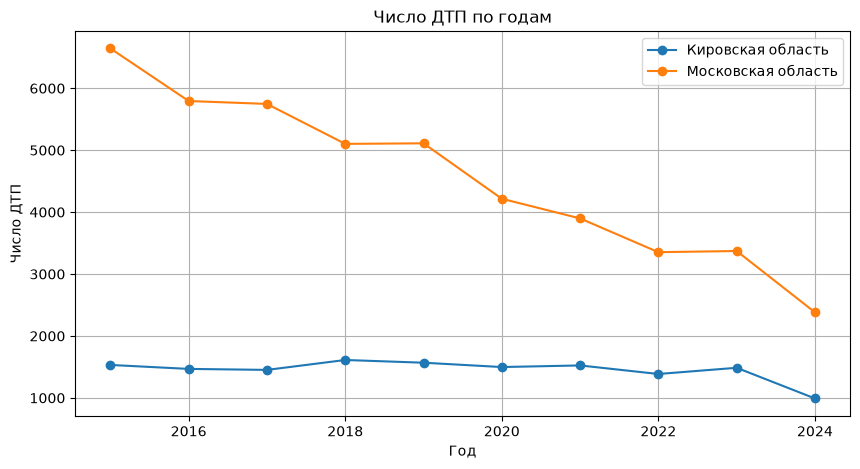

In [26]:
year_counts.plot(kind='line', marker='o', figsize=(10, 5))
plt.title('Число ДТП по годам')
plt.xlabel('Год')
plt.ylabel('Число ДТП')
plt.grid()
plt.show()


### ДТП на 100 тысяч жителей

Для более корректного сравнения областей используем численность населения. В учебном примере значения населения приведены приблизительно по годам. Москва из численности Московской области не учитывается.

Также важно учитывать, что за **2024 год в данных ДТП меньше, чем за предыдущие полные годы**, поэтому этот год нельзя напрямую сравнивать с полными годами без оговорки.


In [27]:
# Численность населения по годам
pop_kirov = {
    2015: 1300000,
    2016: 1300000,
    2017: 1300000,
    2018: 1300000,
    2019: 1300000,
    2020: 1300000,
    2021: 1200000,
    2022: 1100000,
    2023: 1100000,
    2024: 1100000
}

pop_moscow = {
    2015: 7200000,
    2016: 7300000,
    2017: 7400000,
    2018: 7500000,
    2019: 7600000,
    2020: 7700000,
    2021: 8500000,
    2022: 8500000,
    2023: 8600000,
    2024: 8700000
}

per_100k = pd.DataFrame({
    'Кировская область': year_counts['Кировская область'] / pd.Series(pop_kirov) * 100000,
    'Московская область': year_counts['Московская область'] / pd.Series(pop_moscow) * 100000
}).round(2)

per_100k


,Кировская область,Московская область
datetime,,
2015,117.85,92.26
2016,112.92,79.37
2017,111.69,77.66
2018,124.00,68.03
2019,120.62,67.25
2020,115.23,54.75
2021,127.00,45.86
2022,126.00,39.45
2023,135.09,39.21


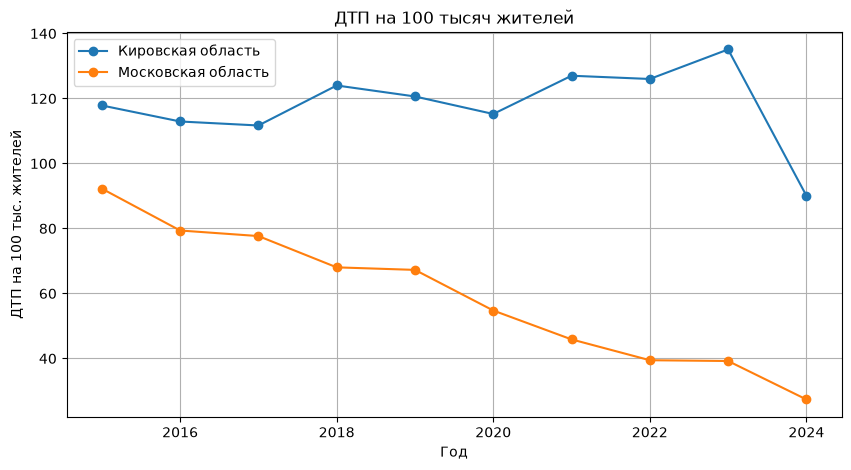

In [28]:
per_100k.plot(kind='line', marker='o', figsize=(10, 5))
plt.title('ДТП на 100 тысяч жителей')
plt.xlabel('Год')
plt.ylabel('ДТП на 100 тыс. жителей')
plt.grid()
plt.show()



По рассчитанному показателю видно, что абсолютное число ДТП и число ДТП на 100 тысяч жителей дают разную картину. Поэтому для сравнения регионов лучше использовать относительный показатель, а не только количество происшествий.


## 9. Общие выводы и рекомендации заказчику

### Качество данных

- Полных дубликатов в таблицах ДТП не обнаружено.
- Идентификаторы ДТП уникальны.
- Есть пропуски в `scheme`, `address`, `point_lat` и `point_long`.
- `datetime` приведён к типу даты и времени.
- Координаты и важные поля желательно сделать обязательными при сборе данных.
- Для `scheme` сначала нужно выяснить причину пропусков, а не заполнять их случайными значениями.

### Время ДТП

- В Кировской области больше всего ДТП приходится на пятницу, в Московской — на субботу.
- В обеих областях максимум ДТП приходится на август.
- Летом ДТП заметно больше, чем в зимние месяцы.
- В 2024 году ДТП меньше, чем в предыдущие годы, поэтому при сравнении нужно учитывать неполный период данных.

### Стаж водителей

- В абсолютном количестве ДТП больше всего приходится на группы со стажем 11–20 лет и более 20 лет.
- По одному количеству ДТП нельзя утверждать, что какая-либо группа водителей более аварийная: для этого нужно знать численность водителей каждой группы.
- Стоит сделать заполнение стажа обязательным.

### Сравнение областей

- В абсолютных значениях ДТП в Московской области больше.
- Для сравнения с учётом размера населения рассчитан показатель ДТП на 100 тысяч жителей.
- Показатель на 100 тысяч жителей в Кировской области в большинстве представленных лет выше, чем в Московской области.
- Для 2024 года нужна отдельная оговорка, потому что количество ДТП в данных ниже, чем за полные предыдущие годы.
